In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import re
import glob
import traceback
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster
from dask.distributed import as_completed as dask_as_completed
import numpy as np
from scipy.interpolate import RBFInterpolator
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def get_allocated_cpus():
    if "SLURM_CPUS_PER_TASK" in os.environ:
        return int(os.environ["SLURM_CPUS_PER_TASK"])
    if "SLURM_CPUS_ON_NODE" in os.environ:
        return int(os.environ["SLURM_CPUS_ON_NODE"])
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return os.cpu_count()
 
 
def get_allocated_memory_gb():
    """
    Best-effort read of the SLURM memory allocation, since dask.distributed
    needs an explicit per-worker memory_limit to manage spilling correctly.
    Falls back to None if it can't be determined -- in that case you MUST
    set SLURM_MEM_GB yourself (see bottom of file) or dask will guess from
    the whole node's memory, which is wrong on a shared node.
    """
    mem_str = os.environ.get("SLURM_MEM_PER_NODE") or os.environ.get("SLURM_MEM_PER_CPU")
    if mem_str is None:
        return None
    mem_mb = int(mem_str)
    if "SLURM_MEM_PER_CPU" in os.environ and "SLURM_MEM_PER_NODE" not in os.environ:
        mem_mb *= get_allocated_cpus()
    return mem_mb / 1024
 
 
def process_single_case(nc_path):
    """
    Processes one case out-of-core via dask-backed
    xarray, computes q_tot, and never materializes the full variable.
    Returns a dict with either results or an "error" key -- never raises,
    so a single bad file doesn't take down the whole batch.
    """
    folder_name = os.path.basename(os.path.dirname(nc_path))
    match = re.search(r"run_tp_([\d\.]+)_ang_([\d\.-]+)", folder_name)
 
    if not match:
        return {"folder": folder_name, "error": "folder name did not match expected pattern"}
 
    tp_val = float(match.group(1))
    ang_val = float(match.group(2))
 
    try:
        with xr.open_dataset(nc_path, chunks={"globaltime": 20}) as ds:
            total_sed = ds["Svsg"] + ds["Svbg"]
 
            time_avg = total_sed.mean(dim="globaltime")

            y_mask = ((ds["globaly"] >= 800) & (ds["globaly"] <= 1200)).compute()
            transport_y_filtered = time_avg.where(y_mask, drop=True)

            # Pick 20 evenly-spaced indices across the filtered ny range
            n_profiles = transport_y_filtered.sizes["ny"]
            idx = np.linspace(0, n_profiles - 1, 20).round().astype(int)
            idx = np.unique(idx)  # avoids duplicate indices if n_profiles < 20

            transport_y_subset = transport_y_filtered.isel(ny=idx)
            profile_1d = transport_y_subset.mean(dim="ny")
 
            x_coord_1d = (ds["globalx"].compute().where(y_mask, drop=True).isel(ny=idx).mean(dim="ny"))
            profile_1d = profile_1d.assign_coords(x_coord=("nx", x_coord_1d.data))

            integrated = profile_1d.integrate(coord="x_coord").compute()
            q_tot_val = integrated.squeeze().item()
 
            return {
                "tp": tp_val,
                "mainang": ang_val,
                "q_tot": q_tot_val,
                "folder": folder_name,
            }
 
    except Exception as e:
        return {
            "folder": folder_name,
            "path": nc_path,
            "error": f"{type(e).__name__}: {e}",
            "trace": traceback.format_exc(),
        }

In [4]:
if __name__ == "__main__":
    run_dir = "xbeach_cases"
    nc_files = sorted(glob.glob(os.path.join(run_dir, "run_tp_*_ang_*", "xboutput.nc")))
    print(f"Found {len(nc_files)} output files to process.")
 
    if not nc_files:
        raise SystemExit("No files found -- check run_dir/glob pattern before proceeding.")
 
    allocated_cpus = get_allocated_cpus()
    allocated_mem_gb = get_allocated_memory_gb()
 
    if allocated_mem_gb is None:
        allocated_mem_gb = float(os.environ.get("SLURM_MEM_GB", 0)) or None
 
    if allocated_mem_gb is None:
        raise SystemExit(
            "Could not determine allocated memory from SLURM env vars. "
            "Set SLURM_MEM_GB=<your job's total memory in GB> before running, "
            "e.g. os.environ['SLURM_MEM_GB'] = '128' at the top of this script."
        )
 
    NUM_WORKERS = int(os.environ.get("NUM_WORKERS_OVERRIDE", min(8, allocated_cpus)))
    mem_per_worker_gb = max(1, int(allocated_mem_gb / NUM_WORKERS * 0.85))  # 15% headroom
 
    print(f"Allocated: {allocated_cpus} CPUs, {allocated_mem_gb:.0f} GB RAM")
    print(f"Using {NUM_WORKERS} dask workers, {mem_per_worker_gb} GB memory_limit each")
 
    cluster = LocalCluster(
        n_workers=NUM_WORKERS,
        threads_per_worker=1,  
        memory_limit=f"{mem_per_worker_gb}GB",
        processes=True,         
        host="127.0.0.1",       
    )
    client = Client(cluster)
    print(f"Dask dashboard: {client.dashboard_link}")
    print("(if running on a remote cluster, you'll need to port-forward this URL to view it)")
 
    # --- Smoke test: process one file before committing the full batch ---
    print("Running smoke test on first file (this may take a while given file size)...")
    smoke_future = client.submit(process_single_case, nc_files[0])
    smoke_result = smoke_future.result()
    if smoke_result.get("error"):
        client.close()
        cluster.close()
        raise RuntimeError(
            f"Smoke test failed on {smoke_result['folder']}: {smoke_result['error']}\n"
            f"{smoke_result.get('trace', '')}"
        )
    print(f"Smoke test OK ({smoke_result['folder']}). Launching full batch...")
 
    futures = client.map(process_single_case, nc_files)
 
    results = []
    errors = []
    completed_count = 0
    for future in dask_as_completed(futures):
        completed_count += 1
        try:
            res = future.result()
        except Exception as e:
            errors.append({"error": f"{type(e).__name__}: {e}"})
            print(f"[{completed_count}/{len(nc_files)}] ✗ worker/task crashed: {e}")
            continue
 
        if res.get("error"):
            errors.append(res)
            print(f"[{completed_count}/{len(nc_files)}] ✗ {res['folder']}: {res['error']}")
        else:
            results.append(res)
            print(f"[{completed_count}/{len(nc_files)}] ✓ {res['folder']}")
 
    client.close()
    cluster.close()
 
    df_results = pd.DataFrame(results)
    df_results.to_csv("q_tot_summary.csv", index=False)
    print(f"\nSuccessfully processed {len(df_results)} / {len(nc_files)} cases.")
 
    if errors:
        df_errors = pd.DataFrame(errors)
        df_errors.to_csv("q_tot_errors.csv", index=False)
        print(f"{len(errors)} cases failed -- see q_tot_errors.csv for details.")

Found 100 output files to process.
Allocated: 10 CPUs, 207 GB RAM
Using 8 dask workers, 21 GB memory_limit each
Dask dashboard: http://127.0.0.1:8787/status
(if running on a remote cluster, you'll need to port-forward this URL to view it)
Running smoke test on first file (this may take a while given file size)...
Smoke test OK (run_tp_10.11_ang_210.00). Launching full batch...
[1/100] ✓ run_tp_11.33_ang_276.67
[2/100] ✓ run_tp_12.56_ang_223.33
[3/100] ✓ run_tp_10.11_ang_250.00
[4/100] ✓ run_tp_10.11_ang_263.33
[5/100] ✓ run_tp_12.56_ang_290.00
[6/100] ✓ run_tp_11.33_ang_210.00
[7/100] ✓ run_tp_10.11_ang_236.67
[8/100] ✓ run_tp_10.11_ang_330.00
[9/100] ✓ run_tp_12.56_ang_236.67
[10/100] ✓ run_tp_12.56_ang_250.00
[11/100] ✓ run_tp_11.33_ang_290.00
[12/100] ✓ run_tp_10.11_ang_316.67
[13/100] ✓ run_tp_10.11_ang_210.00
[14/100] ✓ run_tp_11.33_ang_263.33
[15/100] ✓ run_tp_10.11_ang_290.00
[16/100] ✓ run_tp_11.33_ang_330.00
[17/100] ✓ run_tp_11.33_ang_223.33
[18/100] ✓ run_tp_10.11_ang_303.33

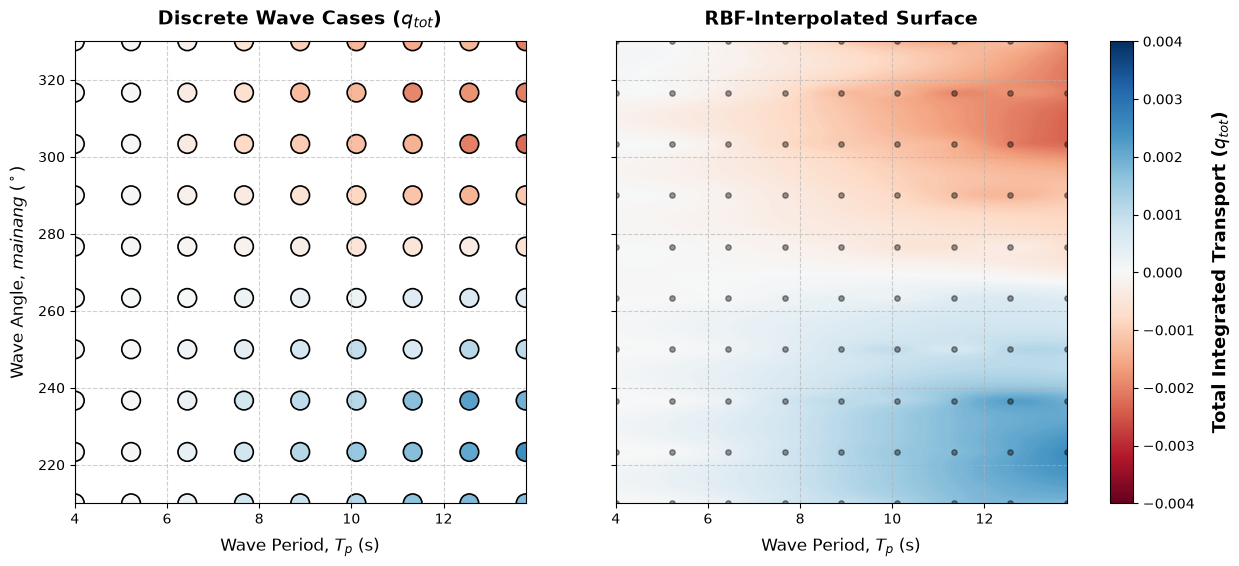

In [3]:
df = pd.read_csv("q_tot_summary.csv")

df_results = df[df["tp"] < 14]

points = df_results[["tp", "mainang"]].to_numpy()
values = df_results["q_tot"].to_numpy()

rbf = RBFInterpolator(
    points,
    values,
    kernel="cubic",
)

tp_lin = np.linspace(df_results["tp"].min(), df_results["tp"].max(), 200)
ang_lin = np.linspace(df_results["mainang"].min(), df_results["mainang"].max(), 200)
tp_grid, ang_grid = np.meshgrid(tp_lin, ang_lin)
grid_points = np.column_stack([tp_grid.ravel(), ang_grid.ravel()])

q_grid = rbf(grid_points).reshape(tp_grid.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

#vmin = df_results["q_tot"].min()
#vmax = df_results["q_tot"].max()

vmin = -.004
vmax = .004

sc = ax1.scatter(
    df_results["tp"], df_results["mainang"], c=df_results["q_tot"],
    cmap="RdBu", s=180, edgecolors="black", linewidths=1.2, vmin=vmin, vmax=vmax,
)
ax1.set_title("Discrete Wave Cases ($q_{tot}$)", fontsize=14, pad=12, weight="bold")
ax1.set_xlabel("Wave Period, $T_p$ (s)", fontsize=12, labelpad=8)
ax1.set_ylabel("Wave Angle, $mainang$ ($^\\circ$)", fontsize=12, labelpad=8)
ax1.grid(True, linestyle="--", alpha=0.6)

cf = ax2.contourf(tp_grid, ang_grid, q_grid, levels=200, cmap="RdBu", vmin=vmin, vmax=vmax)
ax2.scatter(df_results["tp"], df_results["mainang"], color="black", s=15, alpha=0.4, label="Run Locations")
ax2.set_title("RBF-Interpolated Surface", fontsize=14, pad=12, weight="bold")
ax2.set_xlabel("Wave Period, $T_p$ (s)", fontsize=12, labelpad=8)
ax2.grid(True, linestyle="--", alpha=0.6)

cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Total Integrated Transport ($q_{tot}$)", fontsize=13, labelpad=12, weight="bold")

plt.savefig("q_tot_summary_plot_rbf.png", dpi=150)
plt.show()

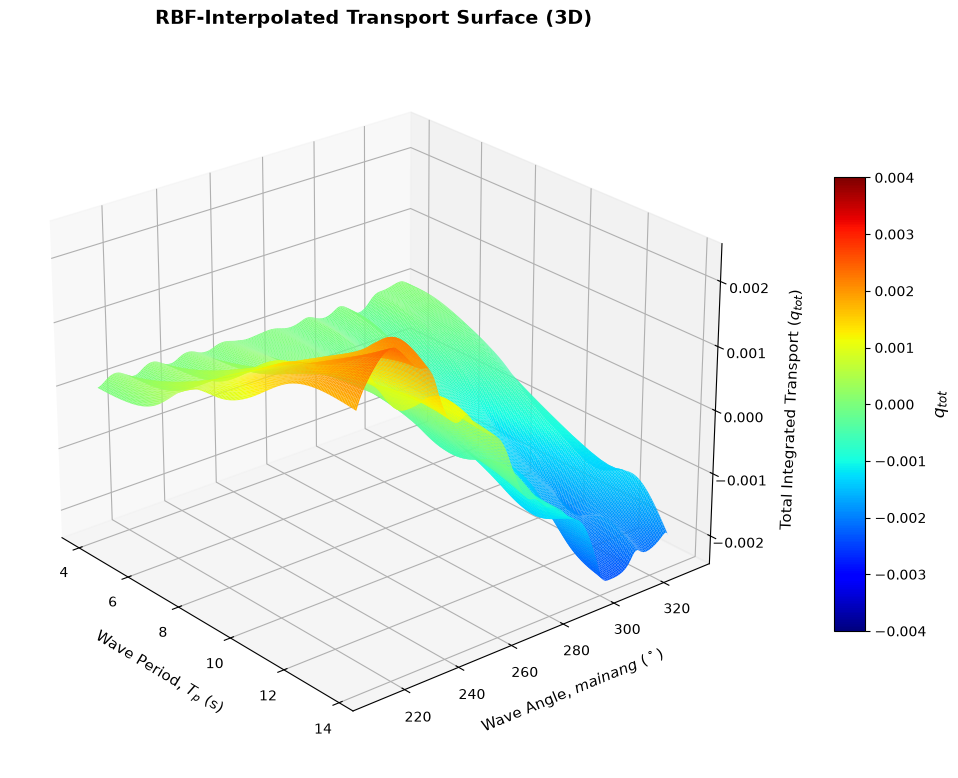

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    tp_grid, ang_grid, q_grid,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    antialiased=True,
    rcount=200,
    ccount=200,
)

ax.set_title("RBF-Interpolated Transport Surface (3D)", fontsize=14, pad=12, weight="bold")
ax.set_xlabel("Wave Period, $T_p$ (s)", fontsize=11, labelpad=10)
ax.set_ylabel("Wave Angle, $mainang$ ($^\\circ$)", fontsize=11, labelpad=10)
ax.set_zlabel("Total Integrated Transport ($q_{tot}$)", fontsize=11, labelpad=10)

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label("$q_{tot}$", fontsize=12, weight="bold")

ax.view_init(elev=25, azim=-40)  # adjust viewing angle to taste

plt.tight_layout()
plt.savefig("q_tot_summary_plot_rbf_3d.png", dpi=150)
plt.show()

In [4]:
ds = xr.open_dataset("xbeach_cases/run_tp_15.00_ang_263.33/xboutput.nc")

wave_params = {}
with open("xbeach_cases/run_tp_15.00_ang_263.33/jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())

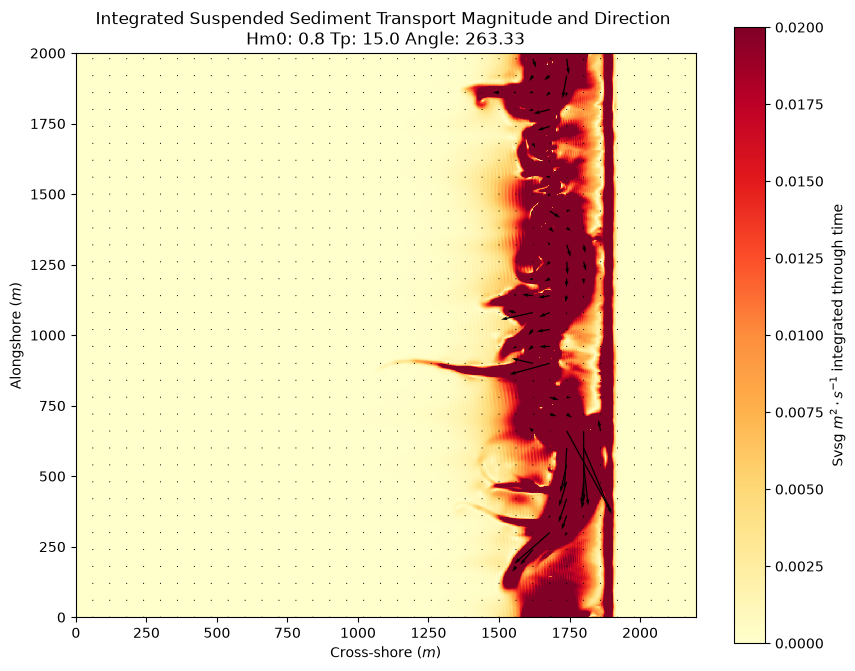

In [9]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Susg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svsg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svsg $m^2 \cdot s^{-1}$ integrated through time')

skip = (slice(None, None, 30), slice(None, None, 30))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=15, width=0.002)

ax.set_title(f"Integrated Suspended Sediment Transport Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()

In [10]:
ds = xr.open_dataset("xbeach_cases/run_tp_15.00_ang_290.00/xboutput.nc")

wave_params = {}
with open("xbeach_cases/run_tp_15.00_ang_290.00/jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())

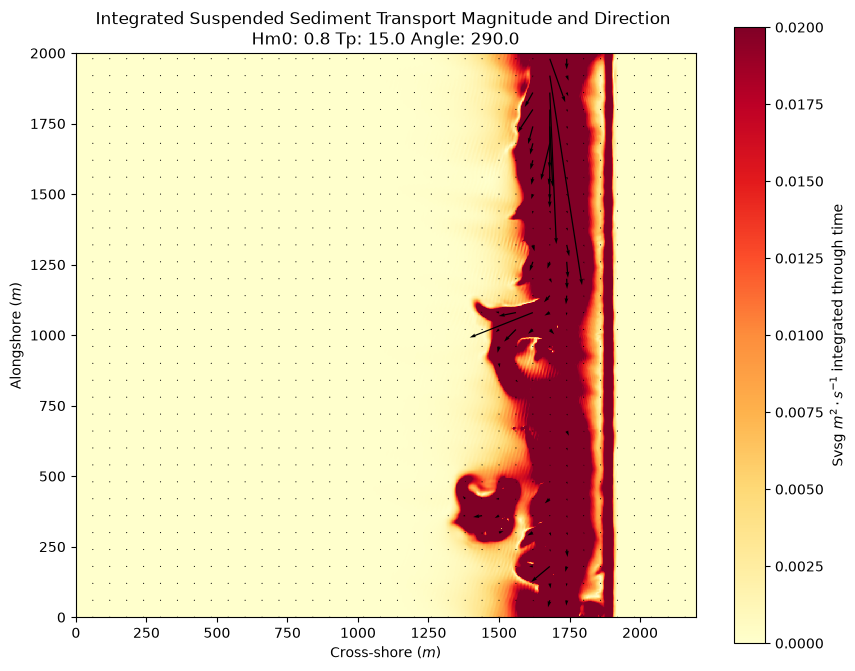

In [11]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Susg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svsg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svsg $m^2 \cdot s^{-1}$ integrated through time')

skip = (slice(None, None, 30), slice(None, None, 30))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=15, width=0.002)

ax.set_title(f"Integrated Suspended Sediment Transport Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()

In [14]:
ds = xr.open_dataset("xbeach_cases/run_tp_13.78_ang_290.00/xboutput.nc")

wave_params = {}
with open("xbeach_cases/run_tp_13.78_ang_290.00/jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())

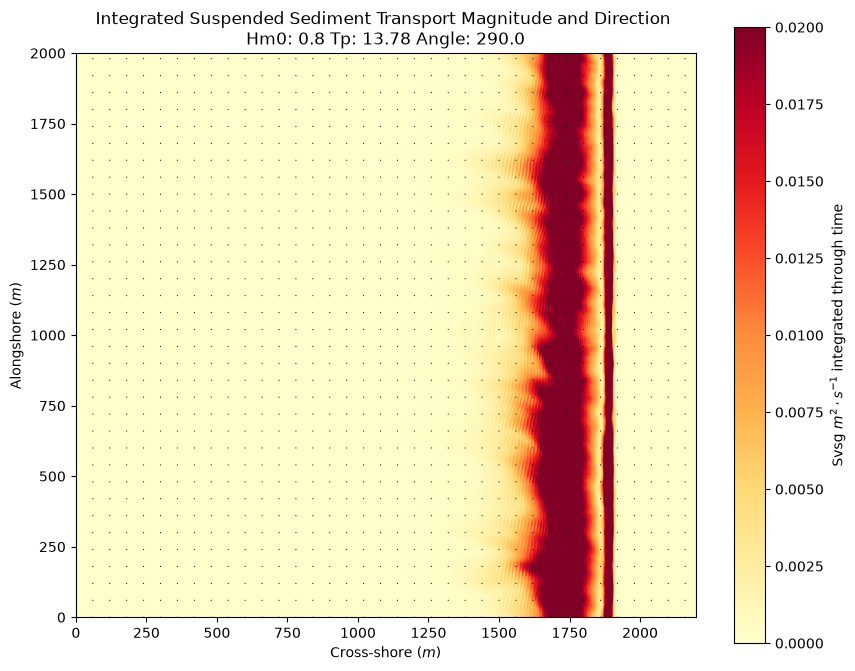

In [15]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Susg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svsg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svsg $m^2 \cdot s^{-1}$ integrated through time')

skip = (slice(None, None, 30), slice(None, None, 30))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=15, width=0.002)

ax.set_title(f"Integrated Suspended Sediment Transport Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()